In [443]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression

In [444]:
df = pd.read_csv('../datasets/wine_data.csv',header=None,usecols=[0,1,2])
df.columns=['Class label','Alcohol','Malic acid']

In [445]:
df = df[['Alcohol','Malic acid','Class label']]

In [446]:
df.head()

,Alcohol,Malic acid,Class label
0,14.23,1.71,1
1,13.20,1.78,1
2,13.16,2.36,1
3,14.37,1.95,1
4,13.24,2.59,1


In [447]:
df.sample(5)

,Alcohol,Malic acid,Class label
30,13.73,1.50,1
48,14.10,2.02,1
148,13.32,3.24,3
1,13.20,1.78,1
27,13.30,1.72,1


In [448]:
df.shape

(178, 3)

In [449]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Alcohol      178 non-null    float64
 1   Malic acid   178 non-null    float64
 2   Class label  178 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 4.3 KB


In [450]:
df.describe()

,Alcohol,Malic acid,Class label
count,178.000000,178.000000,178.000000
mean,13.000618,2.336348,1.938202
std,0.811827,1.117146,0.775035
min,11.030000,0.740000,1.000000
25%,12.362500,1.602500,1.000000
50%,13.050000,1.865000,2.000000
75%,13.677500,3.082500,3.000000
max,14.830000,5.800000,3.000000


In [451]:
df.isnull().sum()

Alcohol        0
Malic acid     0
Class label    0
dtype: int64

In [452]:
X = df[['Alcohol','Malic acid']]
y = df['Class label']

In [453]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [454]:
clf = DecisionTreeClassifier()

In [455]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [456]:
accuracy_score(y_test,y_pred)

0.8055555555555556

In [457]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.7369281045751633)

In [458]:
kbin_alc = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')
kbin_ma = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')

In [459]:
trf = ColumnTransformer([
    ('alc',kbin_alc,[0]),
    ('ma',kbin_ma,[1])
])

In [460]:
X_train

,Alcohol,Malic acid
158,14.34,1.68
137,12.53,5.51
98,12.37,1.07
159,13.48,1.67
38,13.07,1.50
...,...,...
71,13.86,1.51
106,12.25,1.73
14,14.38,1.87
92,12.69,1.53


In [461]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

/Users/asmitbaldi/ML/ML_codes/venv/lib/python3.13/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/Users/asmitbaldi/ML/ML_codes/venv/lib/python3.13/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


In [462]:
trf.named_transformers_['alc'].bin_edges_

array([array([11.03 , 11.798, 12.032, 12.25 , 12.366, 12.51 , 12.708, 12.868,
              13.05 , 13.218, 13.39 , 13.596, 13.756, 13.908, 14.212, 14.83 ])],
      dtype=object)

In [463]:
trf.named_transformers_['ma'].bin_edges_

array([array([0.89 , 1.154, 1.4  , 1.522, 1.64 , 1.68 , 1.73 , 1.81 , 1.954,
              2.142, 2.55 , 3.006, 3.434, 3.872, 4.34 , 5.8  ])             ],
      dtype=object)

In [464]:
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

In [465]:
accuracy_score(y_test,y_pred2)

0.75

In [466]:
np.mean(cross_val_score(DecisionTreeClassifier(),X_train_trf,y_train,cv=10,scoring='accuracy'))

np.float64(0.7247619047619047)

In [467]:
X_trf = trf.fit_transform(X)

/Users/asmitbaldi/ML/ML_codes/venv/lib/python3.13/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/Users/asmitbaldi/ML/ML_codes/venv/lib/python3.13/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


In [468]:
np.mean(cross_val_score(DecisionTreeClassifier(),X_trf,y,cv=10,scoring='accuracy'))

np.float64(0.7137254901960784)

In [469]:
X_trf = pd.DataFrame(X_trf,columns=['Alcohol','Malic acid'])

[]

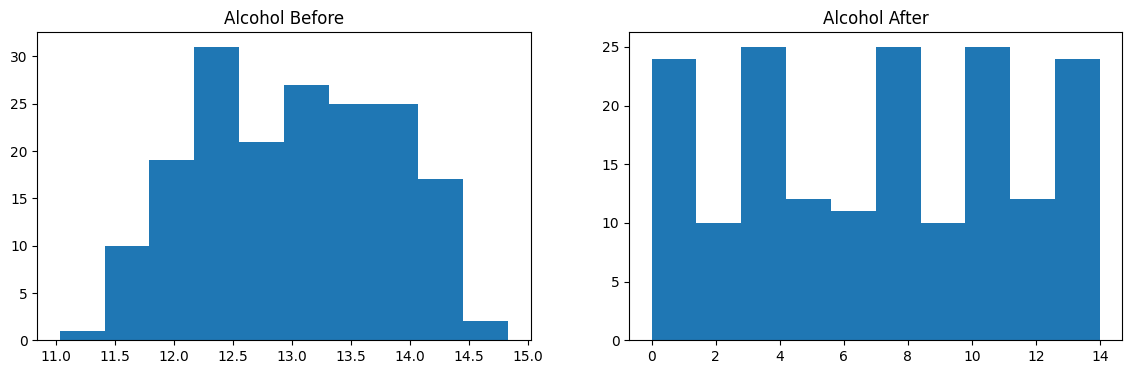

In [470]:
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.hist(X['Alcohol'])
plt.title('Alcohol Before')
plt.subplot(122)
plt.hist(X_trf['Alcohol'])
plt.title('Alcohol After')
plt.plot()

[]

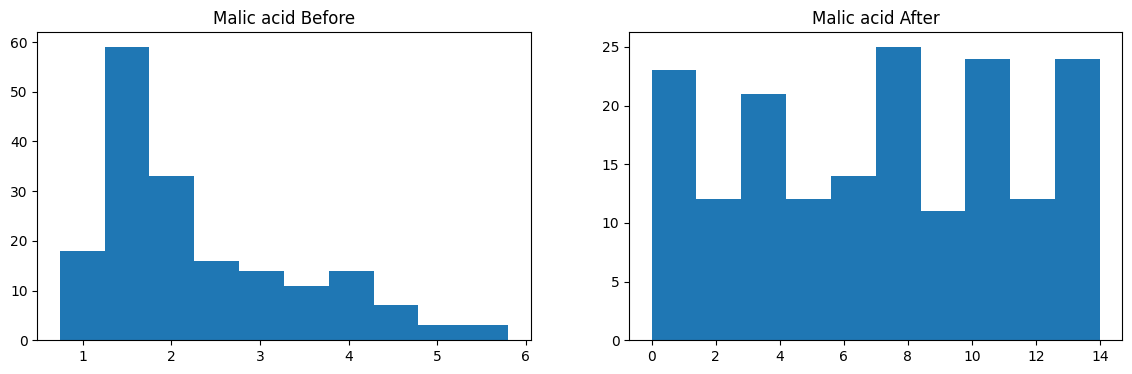

In [471]:
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.hist(X['Malic acid'])
plt.title("Malic acid Before")
plt.subplot(122)
plt.hist(X_trf['Malic acid'])
plt.title('Malic acid After')
plt.plot()

In [472]:
#Now binarization

In [473]:
df.describe()

,Alcohol,Malic acid,Class label
count,178.000000,178.000000,178.000000
mean,13.000618,2.336348,1.938202
std,0.811827,1.117146,0.775035
min,11.030000,0.740000,1.000000
25%,12.362500,1.602500,1.000000
50%,13.050000,1.865000,2.000000
75%,13.677500,3.082500,3.000000
max,14.830000,5.800000,3.000000


In [474]:
X_train

,Alcohol,Malic acid
158,14.34,1.68
137,12.53,5.51
98,12.37,1.07
159,13.48,1.67
38,13.07,1.50
...,...,...
71,13.86,1.51
106,12.25,1.73
14,14.38,1.87
92,12.69,1.53


In [475]:
from sklearn.preprocessing import Binarizer

In [476]:
trf = ColumnTransformer([
    ('full',Binarizer(copy=False,threshold=2.5),[1])
    ],remainder='passthrough')

#After applying ColumnTransformer - [all transformed columns] + [all passthrough columns]

In [477]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [478]:
X_train_trf = pd.DataFrame(X_train_trf,columns=['Malic acid','Alcohol'])

In [479]:
X_train_trf

,Malic acid,Alcohol
0,0.0,14.34
1,1.0,12.53
2,0.0,12.37
3,0.0,13.48
4,0.0,13.07
...,...,...
137,0.0,13.86
138,0.0,12.25
139,0.0,14.38
140,0.0,12.69


In [480]:
X

,Alcohol,Malic acid
0,14.23,1.71
1,13.20,1.78
2,13.16,2.36
3,14.37,1.95
4,13.24,2.59
...,...,...
173,13.71,5.65
174,13.40,3.91
175,13.27,4.28
176,13.17,2.59


In [481]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [482]:
pred = clf.predict(X_test_trf)

/Users/asmitbaldi/ML/ML_codes/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [483]:
accuracy_score(y_test,pred)

0.75

In [484]:
X_trf = trf.fit_transform(X)

In [485]:
np.mean(cross_val_score(DecisionTreeClassifier(),X_trf,y,cv=10,scoring='accuracy'))

np.float64(0.7715686274509804)